# Notebook de Debug OEM (val.json)

Este notebook executa a rede com uma entrada do `val.json`, gera a predição e monta o subplot solicitado:

- Linha 1: imagem original | suporte 1 | suporte 2 | ...
- Linha 2: GT original | máscara 1 | máscara 2 | ... | predição

Ele foi estruturado em 8 seções para facilitar ajustes e reuso.

## 1) Imports e configuração de paths (incluindo Pascal path)

In [16]:
import json
import os
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Path base do projeto fs-cs
PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Imports do projeto
from data.dataset import FSCSDatasetModule
from data.oem import DatasetOEM

from model.asnet import AttentiveSqueezeNetwork
from model.panet import PrototypeAlignmentNetwork
from model.pfenet import PriorGuidedFeatureEnrichmentNetwork
from model.hsnet import HypercorrSqueezeNetwork
from model.asnethm import AttentiveSqueezeNetworkHM

MODEL_DICT = {
    'panet': PrototypeAlignmentNetwork,
    'pfenet': PriorGuidedFeatureEnrichmentNetwork,
    'hsnet': HypercorrSqueezeNetwork,
    'asnet': AttentiveSqueezeNetwork,
    'asnethm': AttentiveSqueezeNetworkHM,
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE =', DEVICE)

# Paleta global de classes (OEM valset)
CLASS_NAMES = {
    0: 'background',
    8: 'road type 2',
    9: 'river',
    10: 'boat & ship',
    11: 'agric land type 2',
}
CLASS_COLORS = {
    0: '#000000',  # background
    8: '#D55E00',  # road type 2
    9: '#0072B2',  # river
    10: '#F0E442', # boat & ship
    11: '#009E73', # agric land type 2
}
CLASS_ORDER = [0, 8, 9, 10, 11]
SEG_CMAP = ListedColormap([CLASS_COLORS[c] for c in CLASS_ORDER])
SEG_NORM = BoundaryNorm(np.arange(-0.5, len(CLASS_ORDER) + 0.5, 1), SEG_CMAP.N)
CLASS_TO_PALETTE_IDX = {cls_id: i for i, cls_id in enumerate(CLASS_ORDER)}

# ===== Configuração editável =====
CFG = {
    # Dados
    'oem_root': '/scratch/matheuspimenta/oem',
    'val_json_name': 'val.json',

    # Path Pascal (mantido por compatibilidade dos checkpoints treinados)
    'pascal_logs_root': 'logs/pascal',

    # Modelo
    'method': 'asnet',  # panet | pfenet | hsnet | asnet | asnethm
    'backbone': 'resnet101',
    'fold': 0,
    'way': 2,
    'shot': 1,

    # Checkpoint (normalmente em logs/pascal/...)
    'ckpt_path': 'logs/pascal/fold0/resnet101/asnet/best_model.ckpt',

    # OEM args
    'oem_train_list': 'train.txt',
    'oem_val_json': 'val.json',
    'oem_test_json': 'test.json',
    'oem_crop_size': 400,
    'support_strategy': 'random',
    'support_area_cache': 'auto',
    'support_similarity_cache': 'auto',
    'support_similarity_size': 32,

    # Outros
    'bgclass': 0,
    'bgd': True,
    'weak': False,
    'rdn_sup': False,
    'benchmark': 'oem',
    'lr': 1e-3,
    'niter': 2000,
    'bsz': 1,
    'nowandb': True,
    'eval': True,
    'resume': False,
    'vis': False,
    'logpath': 'notebook-debug',
    'merge_class': None,
    'oem_sw_enable': False,
    'oem_sw_tile': 400,
    'oem_sw_stride': 312,
}

# Validações de path
assert Path(CFG['oem_root']).exists(), f"OEM root não encontrado: {CFG['oem_root']}"
assert Path(CFG['ckpt_path']).exists(), f"Checkpoint não encontrado: {CFG['ckpt_path']}"
assert Path(CFG['oem_root'], CFG['val_json_name']).exists(), (
    f"val.json não encontrado: {Path(CFG['oem_root'], CFG['val_json_name'])}"
)
assert Path(CFG['pascal_logs_root']).exists(), (
    f"Path Pascal não encontrado: {CFG['pascal_logs_root']}"
)

args = SimpleNamespace(
    datapath=CFG['oem_root'],
    method=CFG['method'],
    backbone=CFG['backbone'],
    fold=CFG['fold'],
    way=CFG['way'],
    shot=CFG['shot'],
    bgclass=CFG['bgclass'],
    bgd=CFG['bgd'],
    weak=CFG['weak'],
    rdn_sup=CFG['rdn_sup'],
    benchmark=CFG['benchmark'],
    lr=CFG['lr'],
    niter=CFG['niter'],
    bsz=CFG['bsz'],
    nowandb=CFG['nowandb'],
    eval=CFG['eval'],
    resume=CFG['resume'],
    vis=CFG['vis'],
    logpath=CFG['logpath'],
    ckptpath=CFG['ckpt_path'],
    merge_class=CFG['merge_class'],
    oem_train_list=CFG['oem_train_list'],
    oem_val_json=CFG['oem_val_json'],
    oem_test_json=CFG['oem_test_json'],
    oem_crop_size=CFG['oem_crop_size'],
    support_strategy=CFG['support_strategy'],
    support_area_cache=CFG['support_area_cache'],
    support_similarity_cache=CFG['support_similarity_cache'],
    support_similarity_size=CFG['support_similarity_size'],
    oem_sw_enable=CFG['oem_sw_enable'],
    oem_sw_tile=CFG['oem_sw_tile'],
    oem_sw_stride=CFG['oem_sw_stride'],
)

print('method:', args.method)
print('checkpoint:', args.ckptpath)
print('val_json:', Path(args.datapath) / args.oem_val_json)
print('palette classes:', {k: CLASS_NAMES[k] for k in CLASS_ORDER if k in CLASS_NAMES})

DEVICE = cuda
method: asnet
checkpoint: logs/pascal/fold0/resnet101/asnet/best_model.ckpt
val_json: /scratch/matheuspimenta/oem/val.json
palette classes: {0: 'background', 8: 'road type 2', 9: 'river', 10: 'boat & ship', 11: 'agric land type 2'}


## 2) Leitura do `val.json` e seleção de um episódio

In [17]:
val_json_path = Path(args.datapath) / args.oem_val_json
with open(val_json_path, 'r', encoding='utf-8') as f:
    val_json = json.load(f)

print('support_set classes:', list(val_json.get('support_set', {}).keys()))
print('num query in val.json:', len(val_json.get('query_set', [])))

# Dataset/loader para episódios de validação
_dm = FSCSDatasetModule(args, img_size=400)
val_dataset = DatasetOEM(
    datapath=args.datapath,
    fold=args.fold,
    transform=_dm.transform,
    split='val',
    way=args.way,
    shot=args.shot,
    bgd=args.bgd,
    rdn_sup=args.rdn_sup,
    oem_train_list=args.oem_train_list,
    oem_val_json=args.oem_val_json,
    oem_test_json=args.oem_test_json,
    oem_crop_size=args.oem_crop_size,
    support_strategy=args.support_strategy,
    support_area_cache=args.support_area_cache,
    support_similarity_cache=args.support_similarity_cache,
    support_similarity_size=args.support_similarity_size,
)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
print('len(val_dataset):', len(val_dataset))


def get_episode_by_index(dataset, idx):
    if idx < 0 or idx >= len(dataset):
        raise IndexError(f'idx={idx} fora de [0, {len(dataset)-1}]')
    return dataset[idx]

# Exemplo de metadados básicos de um episódio
idx_demo = 0
episode_demo = get_episode_by_index(val_dataset, idx_demo)
print('--- Episode demo ---')
print('query_name:', episode_demo['query_name'])
support_names = episode_demo.get('support_names', None)
if support_names is None:
    print('support_names: ausente no episódio')
elif hasattr(support_names, 'shape'):
    print('support_names shape:', tuple(support_names.shape))
elif isinstance(support_names, (list, tuple)):
    print('support_names len:', len(support_names))
else:
    print('support_names type:', type(support_names))
print('support_classes:', episode_demo['support_classes'].tolist())

support_set classes: ['8', '9', '10', '11']
num query in val.json: 30
[val] query entries: 30 (with label: 30, without label: 0)
[val] support entries per class: 8:5, 9:5, 10:5, 11:5
Total val images are : 20
len(val_dataset): 1000
--- Episode demo ---
query_name: valset/labels/dhaka_30.tif
support_names len: 2
support_classes: [9, 10]


## 3) Carregamento do modelo e do checkpoint

In [18]:
model_class = MODEL_DICT[args.method]
model = model_class.load_from_checkpoint(args.ckptpath, args=args)
model = model.to(DEVICE)
model.eval()
print('Modelo carregado:', model.__class__.__name__)


def get_batch_by_index(loader, idx):
    """Retorna batch já colado pelo DataLoader (batch_size=1)."""
    if idx < 0:
        raise IndexError(f'idx={idx} inválido (deve ser >= 0)')
    for i, b in enumerate(loader):
        if i == idx:
            return b
    raise IndexError(f'idx={idx} fora de [0, {len(loader.dataset)-1}]')


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device) if torch.is_tensor(v) else v
    return out

# Teste rápido de consistência de shapes para forward/inferência
test_batch = get_batch_by_index(val_loader, 0)
test_batch_gpu = move_batch_to_device(test_batch, DEVICE)

with torch.no_grad():
    pred_cls_test, pred_seg_test = model.predict_mask_nshot(test_batch_gpu, args.shot)

print('query_img:', tuple(test_batch['query_img'].shape))
print('support_imgs:', tuple(test_batch['support_imgs'].shape))
print('support_masks:', tuple(test_batch['support_masks'].shape))
print('pred_cls:', tuple(pred_cls_test.shape))
print('pred_seg:', tuple(pred_seg_test.shape))

Modelo carregado: AttentiveSqueezeNetwork
query_img: (1, 3, 400, 400)
support_imgs: (1, 2, 1, 3, 400, 400)
support_masks: (1, 2, 1, 400, 400)
pred_cls: (1, 2)
pred_seg: (1, 1024, 1024)


## 4) Pré-processamento da imagem de consulta e do suporte

In [23]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def denormalize_tensor_image(chw):
    """Converte tensor CHW normalizado (ImageNet) para HWC uint8."""
    if isinstance(chw, torch.Tensor):
        arr = chw.detach().cpu().numpy()
    else:
        arr = np.asarray(chw)
    if arr.ndim != 3:
        raise ValueError(f'Esperado CHW 3D, recebido shape={arr.shape}')
    arr = np.transpose(arr, (1, 2, 0))
    arr = arr * IMAGENET_STD + IMAGENET_MEAN
    arr = np.clip(arr, 0.0, 1.0)
    return (arr * 255.0).astype(np.uint8)


def to_hwc_uint8_query(batch, use_raw=False):
    """Por padrao mostra exatamente a entrada da rede (query_img, tipicamente 400x400)."""
    if use_raw and 'query_img_raw' in batch and torch.is_tensor(batch['query_img_raw']):
        raw = batch['query_img_raw'][0].detach().cpu().numpy()
        if raw.ndim == 3 and raw.shape[0] in (1, 3, 4):
            raw = np.transpose(raw, (1, 2, 0))
        if raw.ndim == 2:
            raw = np.stack([raw] * 3, axis=-1)
        if raw.shape[-1] == 1:
            raw = np.repeat(raw, 3, axis=-1)
        raw = np.nan_to_num(raw)
        if raw.dtype != np.uint8:
            vmax = raw.max() if raw.size else 1.0
            vmin = raw.min() if raw.size else 0.0
            if vmax <= 1.0 and vmin >= 0.0:
                raw = (raw * 255.0).astype(np.uint8)
            else:
                raw = np.clip(raw, 0, 255).astype(np.uint8)
        return raw
    return denormalize_tensor_image(batch['query_img'][0])


def flatten_supports(batch):
    """Retorna listas de imagens e máscaras de suporte no formato [N_suportes]."""
    s_imgs = batch['support_imgs'][0]  # [way, shot, C, H, W]
    s_msks = batch['support_masks'][0]  # [way, shot, H, W]

    supports_img, supports_msk = [], []
    for w in range(s_imgs.shape[0]):
        for s in range(s_imgs.shape[1]):
            supports_img.append(denormalize_tensor_image(s_imgs[w, s]))
            supports_msk.append(s_msks[w, s].detach().cpu().numpy())
    return supports_img, supports_msk

## 5) Inferência do modelo para gerar a máscara prevista

## 6) Pós-processamento da saída (resize e métricas opcionais)

In [24]:
def infer_episode(batch, force_input_size=True):
    """Roda inferência n-shot e retorna mapa previsto (classe por pixel)."""
    batch_gpu = move_batch_to_device(batch, DEVICE)

    if force_input_size:
        # Forca saida no tamanho da entrada da rede (query_img), evitando upsample para tamanho original.
        h, w = batch_gpu['query_img'].shape[-2:]
        batch_gpu = dict(batch_gpu)
        batch_gpu['org_query_imsize'] = (
            torch.tensor([w], device=batch_gpu['query_img'].device),
            torch.tensor([h], device=batch_gpu['query_img'].device),
        )

    with torch.no_grad():
        _, pred_seg = model.predict_mask_nshot(batch_gpu, args.shot)  # [B, H, W]
    pred_seg = pred_seg.detach().cpu()
    return pred_seg


def resize_pred_to_query(pred_seg_2d, query_hw):
    """Faz resize da máscara prevista para o tamanho alvo de visualização."""
    h, w = query_hw
    pred = pred_seg_2d[None, None].float()
    pred = F.interpolate(pred, size=(h, w), mode='nearest')
    return pred[0, 0].long().numpy()


def resize_mask_nearest(mask_2d, target_hw):
    """Resize nearest de máscara inteira 2D."""
    h, w = target_hw
    x = torch.from_numpy(mask_2d.astype(np.int64))[None, None].float()
    x = F.interpolate(x, size=(h, w), mode='nearest')
    return x[0, 0].long().numpy()


def compute_iou_and_dice(pred_bin, gt_bin):
    """Métricas binárias simples para foreground (classe != bg)."""
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    iou = float(inter / union) if union > 0 else np.nan

    denom = pred.sum() + gt.sum()
    dice = float((2 * inter) / denom) if denom > 0 else np.nan
    return iou, dice

## 7) Montagem do subplot solicitado (original | suporte... e GT | máscara... | predição)

## 8) Execução por índice e múltiplos exemplos

In [25]:
def get_support_classes_from_batch(batch):
    scls = batch['support_classes']
    if torch.is_tensor(scls):
        if scls.ndim == 2:  # [B, way]
            return scls[0].detach().cpu().tolist()
        if scls.ndim == 1:  # [way]
            return scls.detach().cpu().tolist()
    if isinstance(scls, list) and len(scls) > 0:
        first = scls[0]
        if torch.is_tensor(first):
            return first.detach().cpu().tolist()
        if isinstance(first, (list, tuple)):
            return list(first)
    return []


def episodic_to_global_mask(mask_ep, support_classes):
    """Converte máscara episódica (0..way) para IDs globais de classe (0,8,9,10,11)."""
    out = np.zeros_like(mask_ep, dtype=np.int64)
    for ep_idx, cls_id in enumerate(support_classes, start=1):
        out[mask_ep == ep_idx] = int(cls_id)
    return out


def class_id_to_palette_index(mask_cls):
    """Converte IDs globais de classe para índices da paleta fixa."""
    out = np.zeros_like(mask_cls, dtype=np.int64)
    for cls_id, pal_idx in CLASS_TO_PALETTE_IDX.items():
        out[mask_cls == cls_id] = pal_idx
    return out


def plot_episode_grid(query_rgb, gt_mask, support_rgbs, support_masks, pred_mask, title=''):
    n_support = len(support_rgbs)
    n_cols = max(2 + n_support, 3)

    fig, axes = plt.subplots(2, n_cols, figsize=(4.0 * n_cols, 7.5))

    for r in range(2):
        for c in range(n_cols):
            axes[r, c].axis('off')

    # Linha 1: query original + suportes
    axes[0, 0].imshow(query_rgb)
    axes[0, 0].set_title('Query input (400x400)')

    for i, s_img in enumerate(support_rgbs):
        axes[0, 1 + i].imshow(s_img)
        axes[0, 1 + i].set_title(f'Support {i+1} (400x400)')

    # Linha 2: GT + máscaras dos suportes + predição
    if gt_mask is not None:
        axes[1, 0].imshow(class_id_to_palette_index(gt_mask), cmap=SEG_CMAP, norm=SEG_NORM)
        axes[1, 0].set_title('GT query (400x400)')
    else:
        axes[1, 0].text(0.5, 0.5, 'GT indisponível', ha='center', va='center')
        axes[1, 0].set_title('GT query')

    for i, s_msk in enumerate(support_masks):
        axes[1, 1 + i].imshow(class_id_to_palette_index(s_msk), cmap=SEG_CMAP, norm=SEG_NORM)
        axes[1, 1 + i].set_title(f'Support mask {i+1} (400x400)')

    axes[1, n_cols - 1].imshow(class_id_to_palette_index(pred_mask), cmap=SEG_CMAP, norm=SEG_NORM)
    axes[1, n_cols - 1].set_title('Predição (400x400)')

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def run_episode(idx=0, show_metrics=True):
    batch = get_batch_by_index(val_loader, idx)

    # Exibe exatamente a entrada da rede (query_img), nao a imagem crua original.
    query_rgb = to_hwc_uint8_query(batch, use_raw=False)
    support_rgbs, support_masks_ep = flatten_supports(batch)

    # Forca saida em 400x400 para casar com entrada.
    pred_seg_ep = infer_episode(batch, force_input_size=True)

    support_classes = get_support_classes_from_batch(batch)

    # GT da query (pode não existir em alguns cenários)
    gt_mask_ep = None
    has_gt = bool(batch.get('has_query_mask', torch.tensor([False]))[0].item()) if torch.is_tensor(batch.get('has_query_mask')) else False
    if has_gt and 'query_mask' in batch and torch.is_tensor(batch['query_mask']):
        gt_mask_ep = batch['query_mask'][0].detach().cpu().numpy()

    # Tamanho-alvo de visualização = tamanho de entrada da query
    target_hw = (int(batch['query_img'].shape[-2]), int(batch['query_img'].shape[-1]))

    pred_mask_ep = resize_pred_to_query(pred_seg_ep[0], target_hw)

    if gt_mask_ep is not None and gt_mask_ep.shape != target_hw:
        gt_mask_ep = resize_mask_nearest(gt_mask_ep, target_hw)

    # Conversão de máscaras episódicas -> IDs globais
    pred_mask_cls = episodic_to_global_mask(pred_mask_ep, support_classes)
    support_masks_cls = [episodic_to_global_mask(m, support_classes) for m in support_masks_ep]
    gt_mask_cls = episodic_to_global_mask(gt_mask_ep, support_classes) if gt_mask_ep is not None else None

    qname = batch['query_name'][0] if isinstance(batch.get('query_name', None), list) else str(batch.get('query_name', 'unknown'))
    title = f'idx={idx} | query={qname}'

    if show_metrics and gt_mask_cls is not None:
        # Binário: foreground = classes > 0
        pred_bin = (pred_mask_cls > 0).astype(np.uint8)
        gt_bin = (gt_mask_cls > 0).astype(np.uint8)
        iou, dice = compute_iou_and_dice(pred_bin, gt_bin)
        title += f' | IoU={iou:.4f} | Dice={dice:.4f}'

    plot_episode_grid(
        query_rgb=query_rgb,
        gt_mask=gt_mask_cls,
        support_rgbs=support_rgbs,
        support_masks=support_masks_cls,
        pred_mask=pred_mask_cls,
        title=title,
    )

    org_wh = batch['org_query_imsize']
    if torch.is_tensor(org_wh):
        org_wh = tuple(int(x.item()) for x in org_wh)

    return {
        'idx': idx,
        'query_name': qname,
        'has_gt': has_gt,
        'pred_shape': pred_mask_ep.shape,
        'display_hw': target_hw,
        'query_tensor_shape': tuple(batch['query_img'][0].shape),
        'query_raw_shape': tuple(batch['query_img_raw'][0].shape) if 'query_img_raw' in batch else None,
        'org_query_imsize_wh': org_wh,
        'num_supports': len(support_rgbs),
        'support_classes': support_classes,
        'support_class_names': [CLASS_NAMES.get(int(c), str(c)) for c in support_classes],
    }

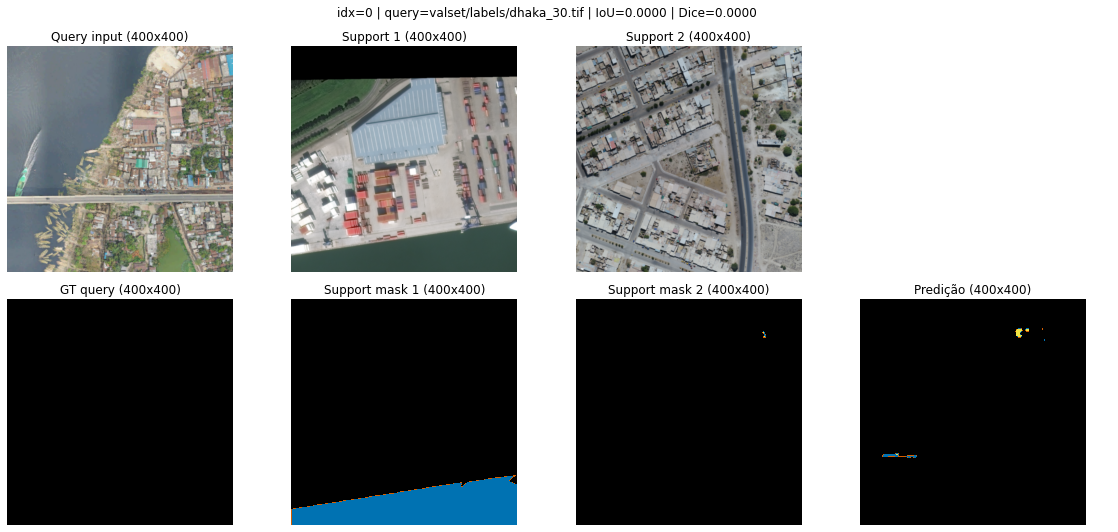

{'idx': 0, 'query_name': 'valset/labels/dhaka_30.tif', 'has_gt': True, 'pred_shape': (400, 400), 'display_hw': (400, 400), 'query_tensor_shape': (3, 400, 400), 'query_raw_shape': (3, 1024, 1024), 'org_query_imsize_wh': [tensor([1024]), tensor([1024])], 'num_supports': 2, 'support_classes': [9, 10], 'support_class_names': ['river', 'boat & ship']}


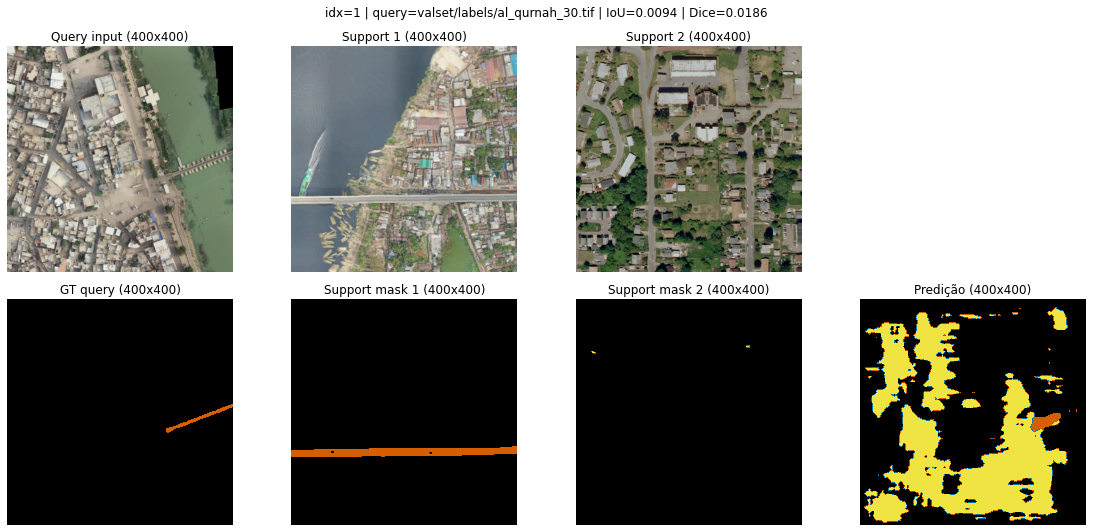

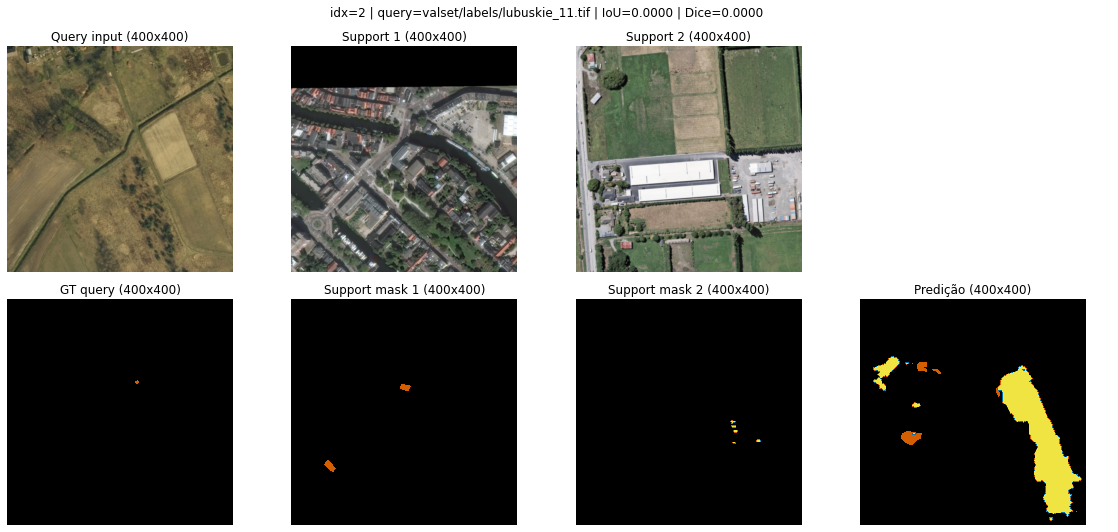

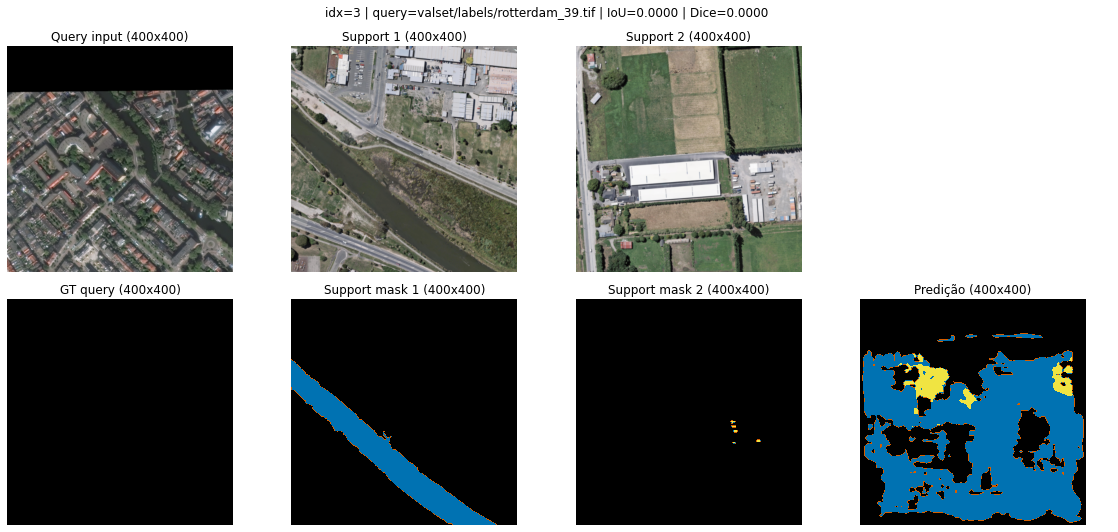

In [26]:
# Execute um episódio específico
info = run_episode(idx=0, show_metrics=True)
print(info)

# Exemplo: múltiplos episódios (ajuste o range conforme quiser)
for i in range(1, min(4, len(val_dataset))):
    _ = run_episode(idx=i, show_metrics=True)